In [1]:
import pandas as pd
import warnings
import numpy as np
warnings.simplefilter(action='ignore', category=FutureWarning)
import matplotlib.pyplot as plt
import math
import seaborn as sns

# General overview of Data

In [2]:
df=pd.read_pickle("D:\solar-performance-monitoring\data\interim\combined_data.pkl")

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\turab\AppData\Local\Temp\ipykernel_2740\2798798191.py:1: SyntaxWarning: invalid escape sequence '\s'
  df=pd.read_pickle("D:\solar-performance-monitoring\data\interim\combined_data.pkl")


In [3]:
df=df.sort_values("date")
df

,date,E-Today(KWH),time/date,event
0,2024-11-16,8,NaT,NaN
1,2024-11-17,40,NaT,NaN
2,2024-11-18,39,NaT,NaN
3,2024-11-19,39,2024-11-19 17:35:06,A1-Grid under voltage
4,2024-11-19,39,2024-11-19 17:35:06,A2-Grid absent
...,...,...,...,...
2053,2026-01-29,16,2026-01-29 10:21:09,A0-Grid over voltage
2054,2026-01-30,25,NaT,NaN
2055,2026-01-31,33,NaT,NaN
2056,2026-02-01,25,NaT,NaN


### Dataset Description

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2058 entries, 0 to 2057
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          2058 non-null   datetime64[ns]
 1   E-Today(KWH)  2058 non-null   int64         
 2   time/date     1820 non-null   datetime64[ns]
 3   event         1820 non-null   object        
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 80.4+ KB


In [5]:
df[df.duplicated(keep=False)]
df = df.drop_duplicates(keep="first")
df[df.duplicated(keep=False)]


,date,E-Today(KWH),time/date,event


In [6]:
df.describe()

,date,E-Today(KWH),time/date
count,2036,2036.000000,1798
mean,2025-07-04 11:01:17.799607296,30.905697,2025-07-08 04:58:09.558954496
min,2024-11-16 00:00:00,1.000000,2024-11-19 17:35:06
25%,2025-03-25 00:00:00,20.000000,2025-03-25 13:17:23.750000128
50%,2025-07-04 12:00:00,31.000000,2025-07-05 10:19:24
75%,2025-10-04 00:00:00,43.000000,2025-10-04 14:33:46.500000
max,2026-02-02 00:00:00,62.000000,2026-01-29 14:18:06
std,NaN,14.338791,NaN


In [7]:
df["date"].unique()

<DatetimeArray>
['2024-11-16 00:00:00', '2024-11-17 00:00:00', '2024-11-18 00:00:00',
 '2024-11-19 00:00:00', '2024-11-20 00:00:00', '2024-11-21 00:00:00',
 '2024-11-22 00:00:00', '2024-11-23 00:00:00', '2024-11-24 00:00:00',
 '2024-11-25 00:00:00',
 ...
 '2026-01-24 00:00:00', '2026-01-25 00:00:00', '2026-01-26 00:00:00',
 '2026-01-27 00:00:00', '2026-01-28 00:00:00', '2026-01-29 00:00:00',
 '2026-01-30 00:00:00', '2026-01-31 00:00:00', '2026-02-01 00:00:00',
 '2026-02-02 00:00:00']
Length: 444, dtype: datetime64[ns]

## IS null event mean that day there is no fault occure

In [8]:
n_e_d=df[df["time/date"].isnull()]
print(len(n_e_d))
n_e_d.drop_duplicates(subset="date",ignore_index=True)
print(len(n_e_d))

238
238


it is proof null mean there is no fault occure that day

## Check Seasonality

<Axes: xlabel='date'>

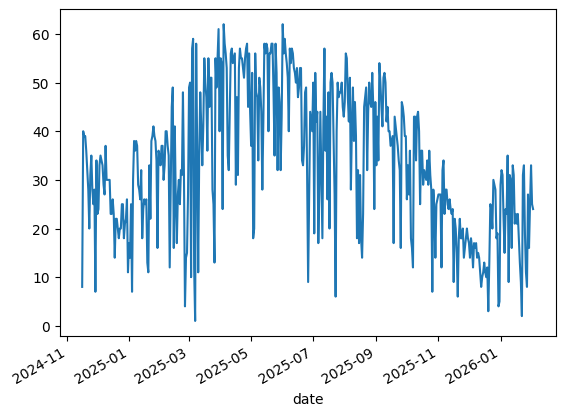

In [9]:
df.set_index("date")["E-Today(KWH)"].plot()

### Event column Description

1️⃣ A0 – Grid Over Voltage 
Meaning:
The inverter detected that the incoming grid voltage exceeded the upper safety limit.

Impact:
Inverter stops power export to protect itself.

2️⃣ A2 – Grid Absent 
Meaning:
The inverter lost grid connection completely.

Impact:
Inverter shuts down because grid reference is missing.

3️⃣ A1 – Grid Under Voltage 
Meaning:
Grid voltage dropped below the minimum operating limit.

Impact:
Inverter reduces output or disconnects.

4️⃣ A4 – Grid Under Frequency 
Meaning:
Grid frequency went below standard (50 Hz in Pakistan).

Impact:
Inverter waits until frequency stabilizes.

5️⃣ no fault 
Meaning:
System running normally.
These logs appear during stable operation.

6️⃣ A3 – Grid Over Frequency 
Meaning:
Grid frequency exceeded normal upper limit (e.g., 50Hz → 51.5Hz).

Impact:
Inverter disconnects for protection.

7️⃣ A6 – Grid Abnormal 

Meaning:
General error combining multiple small abnormalities.
Usually appears when:

Voltage fluctuation + frequency shift together

Impact:
Temporary disconnection.

# check Outliers

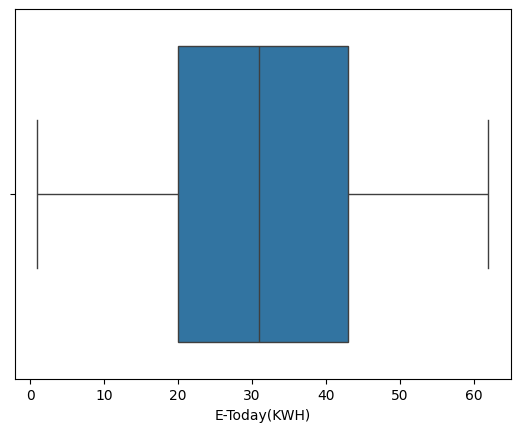

In [10]:
sns.boxplot(x=df["E-Today(KWH)"])
plt.show()

In [11]:
q1=df["E-Today(KWH)"].quantile(.25)
q3=df["E-Today(KWH)"].quantile(.75)
iqr=q3-q1
outlier=df[(df["E-Today(KWH)"]<q1-1.5*iqr) | df["E-Today(KWH)"]>q3-1.5*iqr]
outlier

,date,E-Today(KWH),time/date,event


# Feature Extraction

In [12]:
def get_season(month):
    if month in ["December", "January", "February"]:
        return "Winter"
    elif month in ["March", "April", "May"]:
        return "Spring"
    elif month in ["June", "July", "August"]:
        return "Summer"
    else:
        return "Autumn"


df["months"]=df.date.dt.month_name()
df["days"]=df.date.dt.day_name()
df["years"]=df.date.dt.year
df["week"]=df.date.dt.isocalendar().week
df["DayOfWeek"]=df.date.dt.weekday
df['IsWeekend'] = df['date'].dt.weekday >= 5
df['Quarter'] = df['date'].dt.quarter

df['Season'] = df['months'].apply(get_season)

df



C:\Users\turab\AppData\Local\Temp\ipykernel_2664\70965044.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["months"]=df.date.dt.month_name()
C:\Users\turab\AppData\Local\Temp\ipykernel_2664\70965044.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["days"]=df.date.dt.day_name()
C:\Users\turab\AppData\Local\Temp\ipykernel_2664\70965044.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

,date,E-Today(KWH),time/date,event,months,days,years,week,DayOfWeek,IsWeekend,Quarter,Season
0,2024-11-16,8,NaT,NaN,November,Saturday,2024,46,5,True,4,Autumn
1,2024-11-17,40,NaT,NaN,November,Sunday,2024,46,6,True,4,Autumn
2,2024-11-18,39,NaT,NaN,November,Monday,2024,47,0,False,4,Autumn
3,2024-11-19,39,2024-11-19 17:35:06,A1-Grid under voltage,November,Tuesday,2024,47,1,False,4,Autumn
4,2024-11-19,39,2024-11-19 17:35:06,A2-Grid absent,November,Tuesday,2024,47,1,False,4,Autumn
...,...,...,...,...,...,...,...,...,...,...,...,...
2053,2026-01-29,16,2026-01-29 10:21:09,A0-Grid over voltage,January,Thursday,2026,5,3,False,1,Winter
2054,2026-01-30,25,NaT,NaN,January,Friday,2026,5,4,False,1,Winter
2055,2026-01-31,33,NaT,NaN,January,Saturday,2026,5,5,True,1,Winter
2056,2026-02-01,25,NaT,NaN,February,Sunday,2026,5,6,True,1,Winter


# Missing values treatment

In [13]:
df.isnull().sum()

date              0
E-Today(KWH)      0
time/date       238
event           238
months            0
days              0
years             0
week              0
DayOfWeek         0
IsWeekend         0
Quarter           0
Season            0
dtype: int64

## Event Missing values

In [14]:
df["event"].fillna("no fault",inplace=True)
df["time/date"].fillna("no fault",inplace=True)

C:\Users\turab\AppData\Local\Temp\ipykernel_2664\3452044952.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["event"].fillna("no fault",inplace=True)
C:\Users\turab\AppData\Local\Temp\ipykernel_2664\3452044952.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["time/date"].fillna("no fault",inplace=True)


In [15]:
df.isnull().sum()

date            0
E-Today(KWH)    0
time/date       0
event           0
months          0
days            0
years           0
week            0
DayOfWeek       0
IsWeekend       0
Quarter         0
Season          0
dtype: int64

#  The "Hypothesis/Question-Driven Exploration" stage

## Q1)Does the grid fault lower kwh production

In [16]:
df.reset_index(inplace=True)
df

,index,date,E-Today(KWH),time/date,event,months,days,years,week,DayOfWeek,IsWeekend,Quarter,Season
0,0,2024-11-16,8,no fault,no fault,November,Saturday,2024,46,5,True,4,Autumn
1,1,2024-11-17,40,no fault,no fault,November,Sunday,2024,46,6,True,4,Autumn
2,2,2024-11-18,39,no fault,no fault,November,Monday,2024,47,0,False,4,Autumn
3,3,2024-11-19,39,2024-11-19 17:35:06,A1-Grid under voltage,November,Tuesday,2024,47,1,False,4,Autumn
4,4,2024-11-19,39,2024-11-19 17:35:06,A2-Grid absent,November,Tuesday,2024,47,1,False,4,Autumn
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2031,2053,2026-01-29,16,2026-01-29 10:21:09,A0-Grid over voltage,January,Thursday,2026,5,3,False,1,Winter
2032,2054,2026-01-30,25,no fault,no fault,January,Friday,2026,5,4,False,1,Winter
2033,2055,2026-01-31,33,no fault,no fault,January,Saturday,2026,5,5,True,1,Winter
2034,2056,2026-02-01,25,no fault,no fault,February,Sunday,2026,5,6,True,1,Winter


In [17]:
faults_per_day = df.groupby("date")["event"].apply(lambda x: (x != "no fault").sum())

kwh_per_day = df.groupby("date")["E-Today(KWH)"].mean()

daily_summary = pd.DataFrame({
    "fault_count": faults_per_day,
    "kwh": kwh_per_day
})
daily_summary


,fault_count,kwh
date,,
2024-11-16,0,8.0
2024-11-17,0,40.0
2024-11-18,0,39.0
2024-11-19,3,39.0
2024-11-20,0,36.0
...,...,...
2026-01-29,2,16.0
2026-01-30,0,25.0
2026-01-31,0,33.0


In [18]:
corr = daily_summary["fault_count"].corr(daily_summary["kwh"])
print("Correlation between fault count and kWh:", corr)


Correlation between fault count and kWh: -0.118745761577746


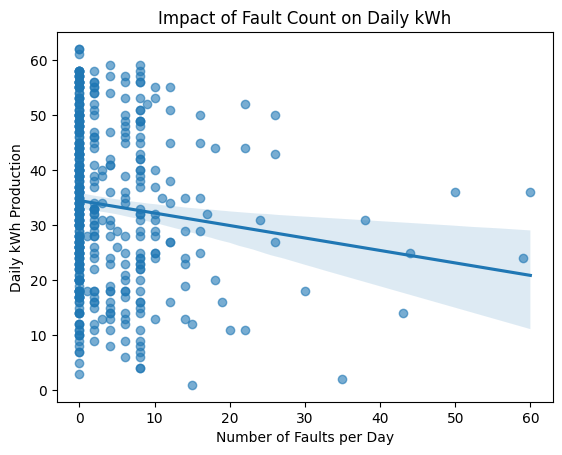

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x="fault_count", y="kwh", data=daily_summary, scatter_kws={"alpha":0.6})
plt.title("Impact of Fault Count on Daily kWh")
plt.xlabel("Number of Faults per Day")
plt.ylabel("Daily kWh Production")
plt.show()


### the above information proof that grid fault is negative correlated to kwh

## Q2) Which months show the highest average energy production?

In [20]:
df.groupby("months").agg({"E-Today(KWH)":"mean"}).sort_values(by="E-Today(KWH)",ascending=False)


,E-Today(KWH)
months,
April,46.355140
June,46.279221
May,40.993590
July,37.791304
September,36.603306
March,32.527344
August,29.430328
October,28.198795
February,27.296774



## Q3. Is energy production increasing or decreasing over the year 2024–2025?

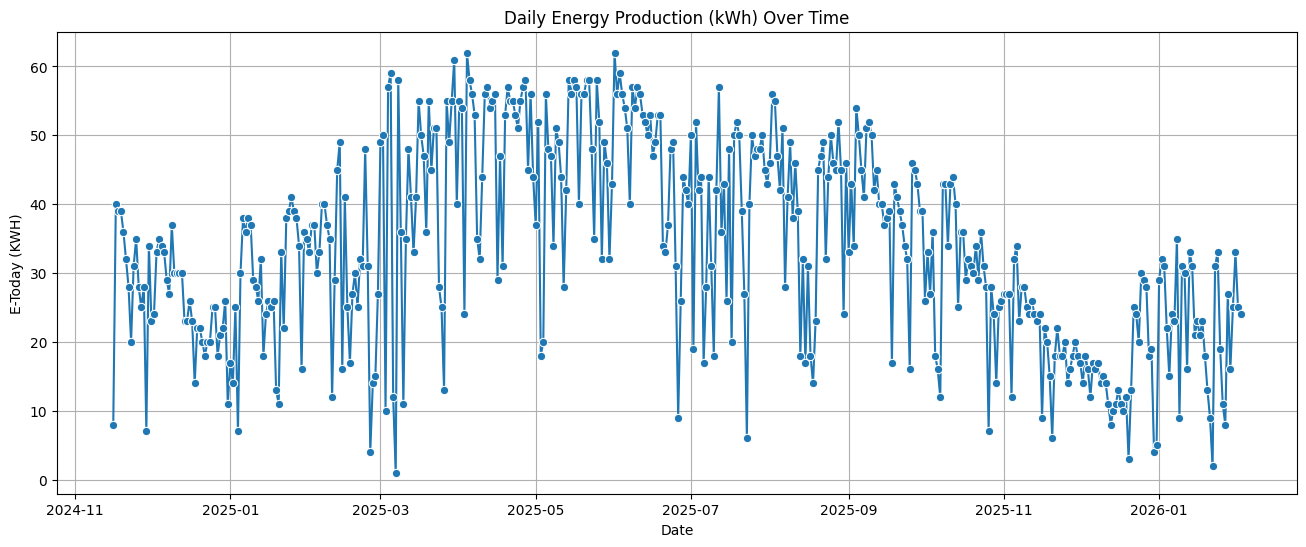

In [21]:
plt.figure(figsize=(16,6))
sns.lineplot(x='date', y='E-Today(KWH)', data=df, marker='o')
plt.title('Daily Energy Production (kWh) Over Time')
plt.xlabel('Date')
plt.ylabel('E-Today (KWH)' )
plt.grid(True)
plt.show()

C:\Users\turab\AppData\Local\Temp\ipykernel_2664\773818312.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_ordinal'] = df['date'].map(pd.Timestamp.toordinal)


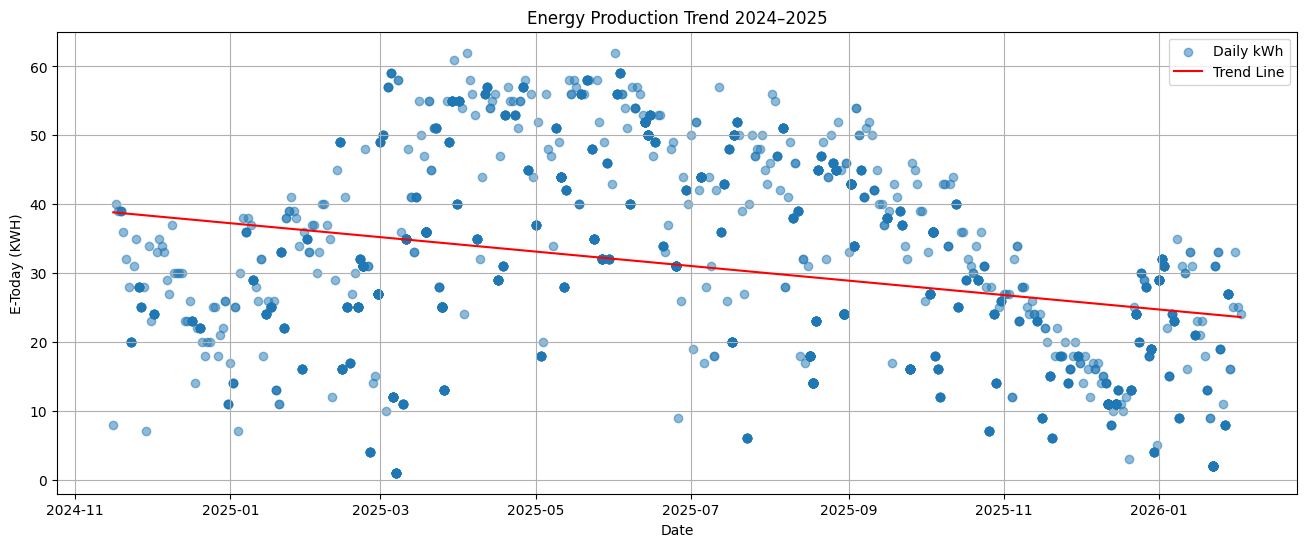

Slope of trend line: -0.03433200250461387


In [22]:
from sklearn.linear_model import LinearRegression
import numpy as np


df['date_ordinal'] = df['date'].map(pd.Timestamp.toordinal)

X = df['date_ordinal'].values.reshape(-1,1)
y = df['E-Today(KWH)'].values

model = LinearRegression()
model.fit(X, y)

# Predicted trend
y_pred = model.predict(X)

plt.figure(figsize=(16,6))
plt.scatter(df['date'], y, alpha=0.5, label='Daily kWh')
plt.plot(df['date'], y_pred, color='red', label='Trend Line')
plt.title('Energy Production Trend 2024–2025')
plt.xlabel('Date')
plt.ylabel('E-Today (KWH)')
plt.legend()
plt.grid(True)
plt.show()

print("Slope of trend line:", model.coef_[0])


## Q4. Which days of the week show the highest average kWh production?

In [23]:
df.groupby("days").agg({"E-Today(KWH)":"mean"}).sort_values(by="E-Today(KWH)",ascending=False)

,E-Today(KWH)
days,
Saturday,36.163889
Wednesday,31.810976
Friday,31.280528
Sunday,31.090090
Tuesday,31.062130
Monday,27.556911
Thursday,24.322176


## Q5. Do weekends produce more or less energy compared to weekdays?

   IsWeekend  E-Today(KWH)
0      False     29.575653
1       True     34.228522


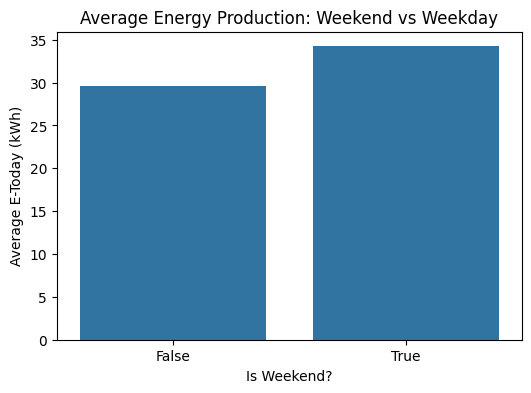

In [24]:
weekend_avg = df.groupby('IsWeekend')['E-Today(KWH)'].mean().reset_index()

print(weekend_avg)

# Plot
plt.figure(figsize=(6,4))
sns.barplot(x='IsWeekend', y='E-Today(KWH)', data=weekend_avg)
plt.title('Average Energy Production: Weekend vs Weekday')
plt.xlabel('Is Weekend?')
plt.ylabel('Average E-Today (kWh)')
plt.show()

## Q6. How does energy production vary across quarters (Q1–Q4)?


In [25]:
quarter_avg = df.groupby('Quarter')['E-Today(KWH)'].agg(['mean','std',"sum"]).reset_index()
print(quarter_avg)



   Quarter       mean        std    sum
0        1  27.188450  13.457675  17890
1        2  44.321343  10.697652  18482
2        3  33.241667  13.252641  15956
3        4  22.029106   9.466123  10596


## Q7. Is there a seasonal trend in power generation (summer vs winter)?


   Season  E-Today(KWH)
0  Autumn     28.604478
1  Spring     37.922929
2  Summer     36.362573
3  Winter     21.742525


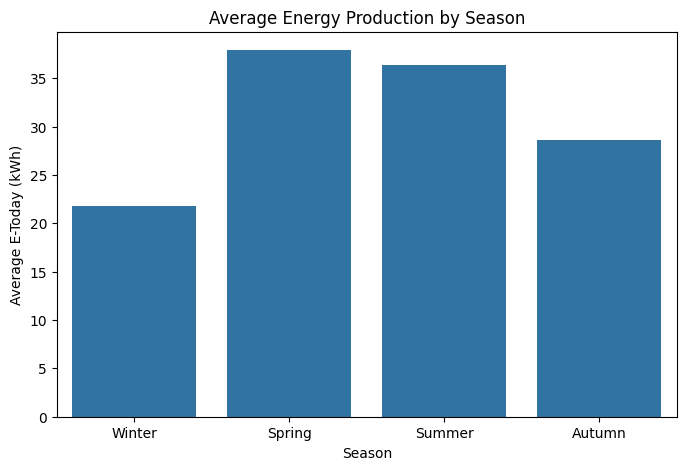

In [26]:
season_avg = df.groupby('Season')['E-Today(KWH)'].mean().reset_index()
print(season_avg)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x='Season', y='E-Today(KWH)', data=season_avg, order=['Winter','Spring','Summer','Autumn'])
plt.title('Average Energy Production by Season')
plt.xlabel('Season')
plt.ylabel('Average E-Today (kWh)')
plt.show()

## Q8. Which specific dates show unusually high or low E-Today values?


In [27]:
mean_kwh = df['E-Today(KWH)'].mean()
std_kwh = df['E-Today(KWH)'].std()

# Define thresholds
high_threshold = mean_kwh + 2*std_kwh
low_threshold = mean_kwh - 2*std_kwh

# Find outlier dates
high_energy_dates = df[df['E-Today(KWH)'] > high_threshold][['date','E-Today(KWH)']]
low_energy_dates = df[df['E-Today(KWH)'] < low_threshold][['date','E-Today(KWH)']]

print("High energy production dates:\n", high_energy_dates)
print("\nLow energy production dates:\n", low_energy_dates)

High energy production dates:
           date  E-Today(KWH)
587 2025-03-30            61
608 2025-04-04            62
859 2025-06-01            62

Low energy production dates:
            date  E-Today(KWH)
376  2025-03-07             1
377  2025-03-07             1
378  2025-03-07             1
379  2025-03-07             1
380  2025-03-07             1
381  2025-03-07             1
382  2025-03-07             1
383  2025-03-07             1
384  2025-03-07             1
385  2025-03-07             1
386  2025-03-07             1
387  2025-03-07             1
388  2025-03-07             1
389  2025-03-07             1
390  2025-03-07             1
1965 2026-01-22             2
1966 2026-01-22             2
1967 2026-01-22             2
1968 2026-01-22             2
1969 2026-01-22             2
1970 2026-01-22             2
1971 2026-01-22             2
1972 2026-01-22             2
1973 2026-01-22             2
1974 2026-01-22             2
1975 2026-01-22             2
1976 2026-01

## 9. Which fault types (A0, A1, A2…) occur most commonly?

event
A0-Grid over voltage       593
A2-Grid absent             357
A1-Grid under voltage      339
A4-Grid under frequency    318
A3-Grid over frequency     176
A6-Grid abnormal            15
Name: count, dtype: int64


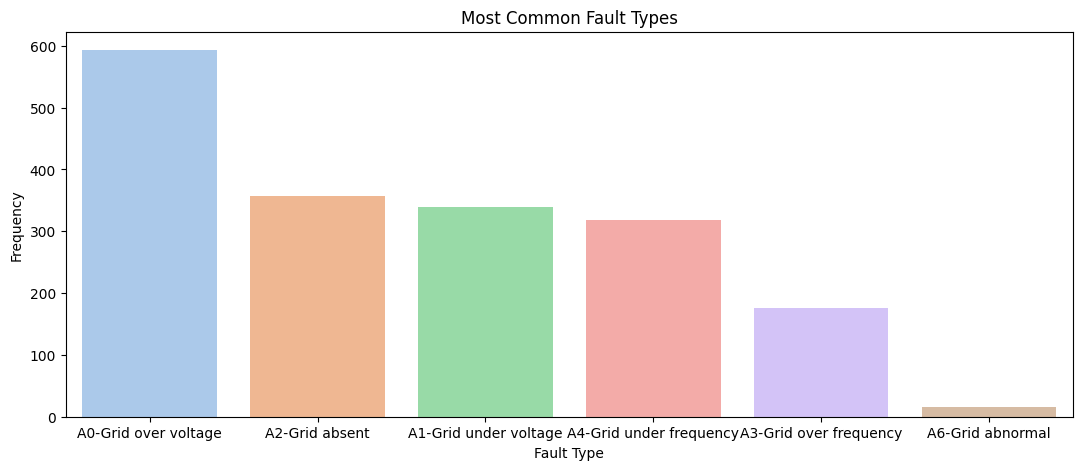

In [28]:
# Exclude 'no fault'
fault_counts = df[df['event'] != 'no fault']['event'].value_counts()
print(fault_counts)

# Plot
plt.figure(figsize=(13,5))
sns.barplot(x=fault_counts.index, y=fault_counts.values, palette='pastel')
plt.title('Most Common Fault Types')
plt.xlabel('Fault Type')
plt.ylabel('Frequency')
plt.show()


## Q10. Which faults are associated with the largest drops in E-Today output?


In [29]:
fault_energy = df[df['event'] != 'no fault'].groupby('event').agg(mean_kWh=('E-Today(KWH)', 'mean'),frequency=('event', 'count'))
# print(fault_energy.sort_values(by="E-Today(KWH)"))
fault_energy['total_impact'] = fault_energy['mean_kWh'] * fault_energy['frequency']

# Sort by total impact
fault_energy = fault_energy.sort_values(by='total_impact', ascending=False)

print(fault_energy)


                          mean_kWh  frequency  total_impact
event                                                      
A0-Grid over voltage     31.013491        593       18391.0
A2-Grid absent           29.380952        357       10489.0
A1-Grid under voltage    30.495575        339       10338.0
A4-Grid under frequency  29.786164        318        9472.0
A3-Grid over frequency   32.295455        176        5684.0
A6-Grid abnormal         11.466667         15         172.0


## Q11. How often do faults occur on days with low energy generation (<20 kWh)?


In [30]:
low_energy_days = df[df['E-Today(KWH)'] < 20]
low_energy_faults = low_energy_days[low_energy_days['event'] != 'no fault']
print("Faults on low-energy days:", low_energy_faults.shape[0])

# Percentage
percentage = (low_energy_faults.shape[0] / low_energy_days.shape[0]) * 100
print(f"Percentage of low-energy days with faults: {percentage:.2f}%")

Faults on low-energy days: 455
Percentage of low-energy days with faults: 92.86%


## Q12. Are certain months more prone to grid-related faults (over-voltage, under-voltage, grid-absent)?


           event
months          
March        256
January      247
August       244
December     200
October      166
May          156
February     155
June         154
September    121
July         115
November     115
April        107


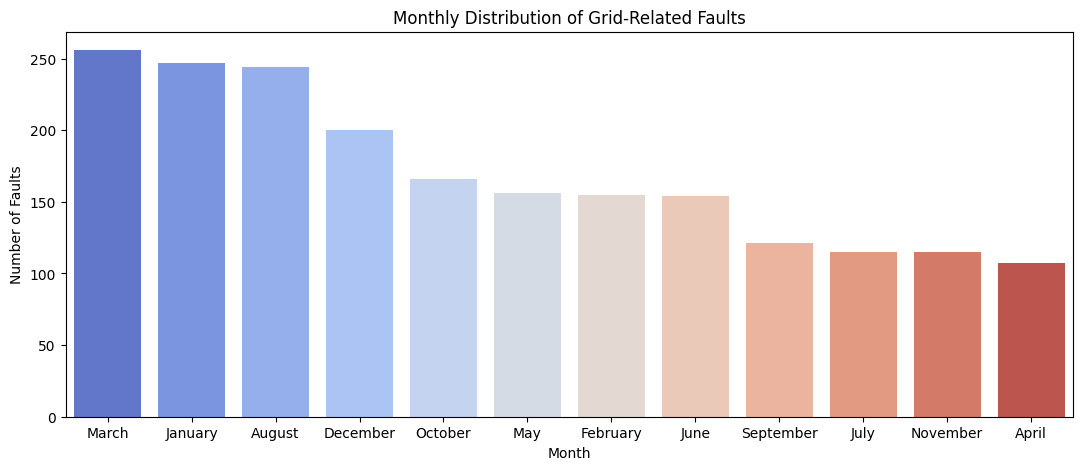

In [31]:
grid_faults = df[df['event']!="no event"]

monthly_faults = grid_faults.groupby('months').agg({"event":"count"}).sort_values(ascending=False,by="event")
print(monthly_faults)

# Plot
plt.figure(figsize=(13,5))
sns.barplot(x=monthly_faults.index, y=monthly_faults["event"], palette='coolwarm')
plt.title('Monthly Distribution of Grid-Related Faults')
plt.xlabel('Month')
plt.ylabel('Number of Faults')
plt.show()

## Q15. Which weeks of the year have the highest average energy production?


In [32]:
# top 5 week 
df.groupby(["years","week"]).agg({"E-Today(KWH)":"mean"}).reset_index().sort_values(by=["years","E-Today(KWH)"],ascending=[True,False]).drop_duplicates(subset="years",keep="first")

,years,week,E-Today(KWH)
5,2024,50,29.000000
24,2025,17,55.150000
60,2026,1,30.162162


## Q16. Do certain months show more variability (higher standard deviation) in production?


In [33]:
df.groupby(["years","months"]).agg({"E-Today(KWH)":"std"}).sort_values(by="E-Today(KWH)",ascending=False)


E-Today(KWH)
years months                 
2025  March         15.411456
      July          14.330984
      August        13.013418
2026  January       11.561827
2025  April         11.195731
      May           10.636211
      September     10.112269
      June           9.574269
      February       9.394147
      October        9.325897
      January        8.110146
2024  November       7.868109
2025  November       6.780392
      December       6.581729
2024  December       5.536655
2026  February       0.707107

## Q17. Does energy production differ significantly between seasons?


In [34]:
df.groupby(["Season"]).agg({"E-Today(KWH)":["mean","std","count"]})

E-Today(KWH)                 
               mean        std count
Season                              
Autumn    28.604478  11.073560   402
Spring    37.922929  14.433907   519
Summer    36.362573  14.367835   513
Winter    21.742525  10.165444   602

In [35]:
from scipy.stats import f_oneway

winter = df[df['Season']=='Winter']['E-Today(KWH)']
spring = df[df['Season']=='Spring']['E-Today(KWH)']
summer = df[df['Season']=='Summer']['E-Today(KWH)']
autumn = df[df['Season']=='Autumn']['E-Today(KWH)']

F, p = f_oneway(winter, spring, summer, autumn)
print("F-statistic:", F)
print("p-value:",p)

F-statistic: 194.94419252242008
p-value: 4.183695051673395e-111


## Q18. Do faults occur more frequently on high-production or low-production days?


In [36]:
df["fault_flag"]=df["event"].apply(lambda x:1 if x!="no fault" else 0)
daily_stats=df.groupby("days").agg({"E-Today(KWH)":"sum","fault_flag":"sum"}).sort_values(by="E-Today(KWH)")

median_prod = daily_stats["E-Today(KWH)"].median()
median_prod
high_prod_faults = daily_stats[daily_stats["E-Today(KWH)"] >= median_prod]["fault_flag"].sum()
low_prod_faults  = daily_stats[daily_stats["E-Today(KWH)"] < median_prod]["fault_flag"].sum()

print("Faults on high-production days:", high_prod_faults)
print("Faults on low-production days:", low_prod_faults)

Faults on high-production days: 1198
Faults on low-production days: 600


C:\Users\turab\AppData\Local\Temp\ipykernel_2664\3334864552.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["fault_flag"]=df["event"].apply(lambda x:1 if x!="no fault" else 0)


## Q19. Is the probability of a fault higher during specific months (e.g., summer heat)?


In [37]:
# Total events per month
total_monthly = df.groupby("months").agg(total_events=("fault_flag", "count"))

# Fault events per month
fault_monthly = df.groupby("months").agg(fault_events=("fault_flag", "sum"))


monthly_stats = total_monthly.join(fault_monthly)


monthly_stats["fault_probability"] = monthly_stats["fault_events"] / monthly_stats["total_events"]

print(monthly_stats.sort_values(by="fault_probability"))

           total_events  fault_events  fault_probability
months                                                  
November            115            90           0.782609
December            200           160           0.800000
July                115            95           0.826087
April               107            89           0.831776
September           121           103           0.851240
February            155           136           0.877419
June                154           136           0.883117
January             247           219           0.886640
May                 156           140           0.897436
October             166           152           0.915663
August              244           230           0.942623
March               256           248           0.968750


## Q20 is there is any relationship between seasons  

In [38]:
import scipy.stats as stats

def relation(pvalue):
    if pvalue<0.05:
        print("there is significant difference btwn category")
    else:
        print("there is no significant difference btwn category")
        
# Suppose you have a 'season' column (categorical)
groups = [df.loc[df['Season'] == s, "E-Today(KWH)"] for s in df['Season'].unique()]
f_stat, p_val = stats.f_oneway(*groups)

relation(p_val)

there is significant difference btwn category


## Q21 is there is any relationship between grid faults 


In [39]:
groups_fault = [df.loc[df['event'] == g, "E-Today(KWH)"]for g in df["event"].unique()]
f_stat_fault, p_val_fault = stats.f_oneway(*groups_fault)

relation(p_val_fault)

there is significant difference btwn category


In [40]:
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# For season
tukey_season = pairwise_tukeyhsd(endog=df["E-Today(KWH)"], groups=df["Season"], alpha=0.05)
print(tukey_season)

# For grid fault
tukey_fault = pairwise_tukeyhsd(endog=df["E-Today(KWH)"], groups=df["event"], alpha=0.05)
print(tukey_fault)


 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
Autumn Spring   9.3185    0.0   7.1584  11.4785   True
Autumn Summer   7.7581    0.0   5.5925   9.9237   True
Autumn Winter   -6.862    0.0   -8.956  -4.7679   True
Spring Summer  -1.5604 0.1951  -3.5845   0.4637  False
Spring Winter -16.1804    0.0 -18.1278  -14.233   True
Summer Winter   -14.62    0.0 -16.5736 -12.6665   True
------------------------------------------------------
                  Multiple Comparison of Means - Tukey HSD, FWER=0.05                  
         group1                  group2         meandiff p-adj   lower    upper  reject
---------------------------------------------------------------------------------------
   A0-Grid over voltage   A1-Grid under voltage  -0.5179 0.9983   -3.363  2.3271  False
   A0-Grid over voltage          A2-Grid absent  -1.6325 0.6017  -4.4316  1.1665  False
   A0-Grid

In [50]:
df.drop(columns="gridfoult",inplace=True)

C:\Users\turab\AppData\Local\Temp\ipykernel_2664\1457803985.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns="gridfoult",inplace=True)


In [51]:
df["gridfault"]=df["event"].apply(lambda x:0 if x=='no fault' else 1)
df.to_pickle("D:\solar-performance-monitoring\data\processed\ml_data.pkl")

C:\Users\turab\AppData\Local\Temp\ipykernel_2664\1355155893.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["gridfault"]=df["event"].apply(lambda x:0 if x=='no fault' else 1)
